### Loading ad preping the data

In [362]:
import pandas as pd
import numpy as np

summary_df = pd.read_csv("summary.csv")
static_df = pd.read_csv("static.csv")
df = summary_df.merge(static_df, on = "RunID", how = "inner")
feature_cols = [
        # "max_cpu_usage_percent",
        "mean_cpu_usage_percent",
        # "max_ram_used_mb",
        "mean_ram_used_mb",
        "time_per_1000_steps_sec"
    ]
assert len(df) == len(summary_df), "Different number of entries"
# print(df.head())
print(static_df["game_name"].value_counts(normalize=True))
print(static_df["training_type"].value_counts(normalize=True))

game_name
3DBall               0.460666
3DBallHard           0.339121
Crawler              0.071580
GridFoodCollector    0.057229
PushBlock            0.029943
Hallway              0.021262
Pyramids             0.004429
Walker               0.004429
Worm                 0.004429
Sorter               0.003898
GridWorld            0.003012
Name: proportion, dtype: float64
training_type
ppo    0.980865
sac    0.019135
Name: proportion, dtype: float64


,RunID,final_reward,max_reward,time_to_max_reward_sec,total_duration_sec,mean_policy_loss,mean_value_loss,mean_entropy,final_entropy,max_cpu_usage_percent,...,normalize,hidden_units,num_layers,vis_encode_type,reward_extrinsic_gamma,reward_extrinsic_strength,keep_checkpoints,max_steps,time_horizon,summary_freq
5562,20251222-081952,4.246524,4.246524,488.350616,488.350616,-2.815203,0.008457,1.288776,1.212161,22.000000,...,True,128,2,simple,NaN,NaN,5,100000,1024,10000
5573,20251221-200444,44.108116,100.000015,1950.913330,43095.429688,-0.999724,0.000093,-0.428936,-0.499910,26.612499,...,True,512,2,simple,NaN,NaN,5,2000000,256,50000
5574,20251221-193545,100.000008,100.000008,189.247040,1723.118652,-11.089017,0.009682,0.226602,-0.104522,29.500000,...,False,128,2,simple,NaN,NaN,5,500000,64,10000
5587,20251222-080348,100.000015,100.000015,748.948975,951.291809,-0.789231,0.000635,0.702443,0.309381,22.272728,...,False,64,2,simple,NaN,NaN,5,250000,1024,50000
5593,20251220-225054,90.438469,100.000008,416.539246,1446.090088,0.023657,0.668595,1.268878,1.222409,30.650000,...,False,512,1,simple,NaN,NaN,5,2000000,64,12000
5608,20251220-215640,10.510101,12.801076,1503.668823,1517.817627,0.012006,0.051651,1.373494,1.341288,71.050003,...,False,512,1,simple,NaN,NaN,5,2000000,64,12000
5623,20251222-082820,96.176491,98.078865,2809.999512,3132.610352,-13.110937,0.001809,-0.539744,-0.964242,18.288889,...,False,128,1,simple,NaN,NaN,5,500000,256,50000
5638,20251220-222211,2.465476,2.465476,790.763794,790.763794,0.017488,0.376545,1.405304,1.394899,35.000000,...,True,32,3,simple,NaN,NaN,5,1000000,128,12000
5641,20251220-223532,100.000015,100.000015,366.650116,840.419006,0.025297,0.030919,1.226483,1.040945,39.799999,...,True,64,1,simple,NaN,NaN,5,1000000,512,12000
5643,20251220-224942,1.198276,1.198276,62.745682,62.745682,NaN,NaN,1.418938,1.418938,30.400000,...,True,128,2,simple,NaN,NaN,5,100000,128,12000


In [ ]:
def create_feature_data_frame(df : pd.DataFrame) -> pd.DataFrame:
    assert (df["max_steps"] > 0).all(), "Runs with 0 steps found"
    df["time_per_1000_steps_sec"] = (df["total_duration_sec"]/df["max_steps"]*1000)
    return df[feature_cols]
    
def get_sanitized_mask(X : pd.DataFrame):
    sanitized_mask =(
        # (X["max_cpu_usage_percent"] >= 0) &
        (X["mean_cpu_usage_percent"] >= 0) &
        # (X["max_ram_used_mb"] >= 0) &
        (X["mean_ram_used_mb"] >= 0) &
        (X["time_per_1000_steps_sec"] > 0)
    )
    return sanitized_mask

X = create_feature_data_frame(df)
sanitized_mask = get_sanitized_mask(X)
X_sanitized = X[sanitized_mask].copy()
df_sanitized = df[sanitized_mask].copy()

def get_sanitized_features_and_org_df(df : pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = create_feature_data_frame(df)
    sanitized_mask = get_sanitized_mask(X)
    X_sanitized = X[sanitized_mask].copy()
    df_sanitized = df[sanitized_mask].copy()
    return X_sanitized, df_sanitized

print(f"Number of significantly long runs (time_per_1000_stpes_sec > 10) : {len(X[X["time_per_1000_steps_sec"]>10])}")
print(f"Number of deleted entries : {len(X) - len(X_sanitized)}")


Number of significantly long runs (time_per_1000_stpes_sec > 10) : 83
Number of deleted entries : 2


In [377]:
filtered = (df["game_name"] == "3DBall") & (df["training_type"] == "sac")
X_sanitized[filtered].describe()

/var/folders/fp/hb4266ks69q8sbbntv5rmj2w0000gn/T/ipykernel_45338/1868267825.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_sanitized[filtered].describe()


,mean_cpu_usage_percent,mean_ram_used_mb,time_per_1000_steps_sec
count,29.000000,29.000000,29.000000
mean,21.692960,11413.359288,14.164921
std,6.211005,7233.337737,12.762030
min,9.701604,2904.025830,2.918337
25%,17.646125,3591.258325,4.883506
50%,22.218167,10893.118750,8.356691
75%,24.844500,18236.522500,21.547715
max,33.671000,21726.773315,57.721363


In [318]:
import matplotlib.pyplot as plt

def plot_distribuiton_of_features() -> None:        
    for col in feature_cols:
        plt.figure()
        plt.hist(X[col].dropna(), bins=100)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    plt.figure()
    selected = X[X["time_per_1000_steps_sec"] > 10]
    plt.hist(selected["time_per_1000_steps_sec"].dropna(), bins=100)
    plt.title(f"Distribution of time_per_1000_steps_sec")
    plt.xlabel("time_per_1000_steps_sec")
    plt.ylabel("Count")
    plt.show()
    
# plot_distribuiton_of_features()


In [ ]:
print(static_df.cpu.unique())
print(len(static_df[static_df["cpu"] == "AMD Ryzen 7 9800X3D 8-Core Processor"]))
# test = static_df[static_df["cpu"] == "Apple M1"]
# print(test["game_name"].value_counts())
test = static_df[(static_df["cpu"] == "AMD Ryzen 7 9800X3D 8-Core Processor") & (static_df["training_type"] == "sac")]
print(test["training_type"].value_counts())
print(test["game_name"].value_counts())
test = static_df[(static_df["cpu"] == "Apple M1") & (static_df["training_type"] == "sac")]
print(len(test))

['AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD' 'Apple M2'
 'AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD'
 'AMD Ryzen 7 9800X3D 8-Core Processor'
 'AMD Ryzen 7 5700X 8-Core Processor' 'Apple M1']
4144
training_type
sac    8
Name: count, dtype: int64
game_name
Crawler              1
GridFoodCollector    1
Hallway              1
PushBlock            1
Pyramids             1
Sorter               1
Walker               1
Worm                 1
Name: count, dtype: int64
38


In [335]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def get_scaled_df_and_np(X_sanitized : pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    scaler = RobustScaler()
    X_scaled_as_array = scaler.fit_transform(X_sanitized)
    X_scaled = pd.DataFrame(
        X_scaled_as_array,
        columns=X_sanitized.columns,
        index = X_sanitized.index
    )
    return X_scaled, X_scaled_as_array

def cluster(X_scaled_as_array : np.ndarray, n_init = "auto", n_clusters = 5) -> tuple[np.ndarray, KMeans]:
    clf = KMeans(n_clusters=n_clusters, random_state=42, n_init=n_init, init="k-means++")
    clusters = clf.fit_predict(X_scaled_as_array)    
    return clusters, clf
    
def cluster_and_show(n_init = "auto", n_clusters = 5) -> None:
    X_sanitized, df_sanitized = get_sanitized_features_and_org_df(df)
    X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
    X_scaled.describe()

    X_scaled["clusters"] = cluster(X_scaled_as_array, n_init=n_init, n_clusters = n_clusters)[0]
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c = X_scaled["clusters"])
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

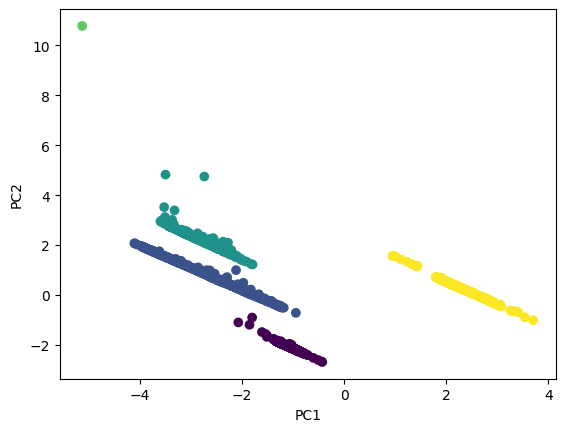

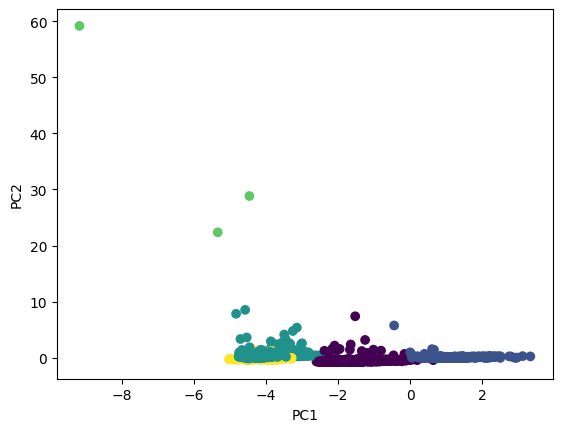

In [312]:
cluster_and_show(n_init="auto")
cluster_and_show(n_init=10)



In [300]:
import numpy as np
pca = PCA(n_components=2)
X_sanitized, df_sanitized = get_sanitized_features_and_org_df(df)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
X_pca_1 = pca.fit_transform(X_scaled)
X_pca_2 = pca.fit_transform(X_scaled)

np.allclose(X_pca_1, X_pca_2)

labels_auto = KMeans(n_clusters=5, n_init="auto", random_state=42).fit_predict(X_scaled)
labels_10 = KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(X_scaled)

(labels_auto == labels_10).mean()


0.06132577100319036

In [301]:
clusters, clf = cluster(X_scaled_as_array)
X_sanitized["cluster"] = clf.labels_
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
# print(cluster_summary)
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = X_sanitized["cluster"]
# static_cluster_3 = df_sanitized.loc[X_sanitized["cluster"] == 3]
# print(static_cluster_3)
# static_cluster_3.head()
# X_sanitized[X_sanitized["cluster"] == 3]["RunID"]
# X_sanitized
# print(summary_df_sanitized[X_sanitized["cluster"] == 3])
# df_sanitized[X_sanitized["cluster"] == 3]
# df_sanitized_with_clusters.head()
print(df_sanitized_with_clusters.columns)
print(X_sanitized["cluster"].value_counts())

Index(['RunID', 'final_reward', 'max_reward', 'time_to_max_reward_sec',
       'total_duration_sec', 'mean_policy_loss', 'mean_value_loss',
       'mean_entropy', 'final_entropy', 'max_cpu_usage_percent',
       'mean_cpu_usage_percent', 'max_ram_used_mb', 'mean_ram_used_mb',
       'mean_cpu_frequency', 'max_cpu_frequency', 'max_gpu_usage_percent',
       'mean_gpu_usage_percent', 'max_vram_used_mb', 'mean_vram_used_mb',
       'max_game_cpu_usage_percent', 'mean_game_cpu_usage_percent',
       'max_game_memory_usage_mb', 'mean_game_memory_usage_mb', 'os', 'cpu',
       'physical_cores', 'system_ram_gb', 'gpu', 'GPU_ram_mb', 'cuda_version',
       'training_type', 'game_name', 'batch_size', 'learning_rate',
       'buffer_size', 'beta', 'epsilon', 'lambd', 'num_epoch',
       'learning_rate_schedule', 'normalize', 'hidden_units', 'num_layers',
       'vis_encode_type', 'reward_extrinsic_gamma',
       'reward_extrinsic_strength', 'keep_checkpoints', 'max_steps',
       'time_horizon',

In [281]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"])

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
0,1450,16,4,17,0,2,5,2,1,2,3
1,215,21,161,143,7,3,142,1,2,1,1
2,647,1769,100,107,0,94,1,0,0,0,0
3,105,42,69,22,1,16,16,15,11,15,16
4,0,0,0,0,1,0,0,0,1,0,0
5,3,0,4,5,1,0,0,1,2,1,0
6,180,66,64,29,7,5,5,6,4,6,5
7,0,0,0,0,0,0,0,0,1,0,0


In [282]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"])

training_type,ppo,sac
cluster,,
0,1494,8
1,672,25
2,2718,0
3,277,51
4,0,2
5,10,7
6,363,14
7,0,1


In [283]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["cpu"])

cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
0,20,1437,0,45,0,0
1,641,0,56,0,0,0
2,9,2704,0,5,0,0
3,0,0,0,0,80,248
4,2,0,0,0,0,0
5,1,1,0,0,2,13
6,278,0,99,0,0,0
7,0,0,0,0,1,0


In [ ]:
display(cluster_summary)
display(df_sanitized_with_clusters)

max_cpu_usage_percent                                    \
                         mean        std        min         max   
cluster                                                           
0                   70.161232   5.716911  16.350000  100.000000   
1                   15.776273   8.978645   3.133333   57.099998   
2                   73.556731   5.337323  32.750000  100.000000   
3                   40.921222  15.331451  17.944445   96.000000   
4                   16.080000   1.442498  15.060000   17.100000   
5                   58.785098  19.619260  25.133333   81.849998   
6                    8.342799   4.947143   2.366667   37.549999   
7                   29.100000        NaN  29.100000   29.100000   

        mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
0                    63.388139   5.973617   5.927114  74.194779   
1                     8.803662   5.285194   1.924797  25.707083   
2                    64.864863   3.361515   8.278125  94.356250   
3                    28.232567   7.767170  16.153333  59.314584   
4                    14.457917   1.457229  13.427500  15.488333   
5                    34.835025  11.091579  14.170000  55.329807   
6                     4.635513   3.602566   1.505000  22.297500   
7                    24.949333        NaN  24.949333  24.949333   

        max_ram_used_mb                                           \
                   mean          std           min           max   
cluster                                                            
0          20288.769349  1063.744202  17545.666016  28421.500000   
1          18012.511846  2634.414823  14286.000000  32444.000000   
2          23105.079678  1116.950121  21358.666016  34953.000000   
3           3715.647545   336.534151   2692.666748   4893.333496   
4          15737.599609  6453.904461  11174.000000  20301.199219   
5           6146.829073  6393.245687   3216.199951  26269.000000   
6          10553.772817  1571.876993   7154.000000  16315.000000   
7           3780.000000          NaN   3780.000000   3780.000000   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
0           20152.961870   986.492928  15108.094527  25133.583333   
1           17223.645046  2227.172045  10893.118750  23880.514851   
2           22863.418039   832.976719  19919.188818  29360.436747   
3            3564.794644   301.559412   2588.723328   4527.621951   
4           14264.570630  4899.312835  10800.233301  17728.907959   
5            5093.585949  4546.032865   2823.696663  19176.105469   
6           10222.952518  1303.261881   7092.654632  14025.141748   
7            3093.520010          NaN   3093.520010   3093.520010   

        time_per_1000_steps_sec                                     
                           mean        std         min         max  
cluster                                                             
0                      0.483715   1.120795    0.230291   23.334980  
1                      1.910339   4.824974    0.223165   57.721363  
2                      0.445380   0.252847    0.210316    4.730606  
3                      3.467460   5.206633    0.427554   32.024634  
4                    399.798652  72.003606  348.884414  450.712891  
5                     64.451544  33.530936   32.111572  132.191891  
6                      1.271411   2.736747    0.349650   23.341519  
7                    912.552125        NaN  912.552125  912.552125

,RunID,final_reward,max_reward,time_to_max_reward_sec,total_duration_sec,mean_policy_loss,mean_value_loss,mean_entropy,final_entropy,max_cpu_usage_percent,...,num_layers,vis_encode_type,reward_extrinsic_gamma,reward_extrinsic_strength,keep_checkpoints,max_steps,time_horizon,summary_freq,time_per_1000_steps_sec,cluster
0,20251123-014754,58.578957,58.578957,636.410400,636.410400,0.017760,0.645102,1.387867,1.353453,8.000000,...,1,simple,NaN,NaN,5,1000000,512,12000,0.636410,1
1,20251123-015841,5.235752,5.377958,550.640808,595.175354,0.024710,0.018888,1.398695,1.383176,10.500000,...,2,simple,NaN,NaN,5,1000000,128,12000,0.595175,6
2,20251123-020847,1.249706,1.367556,202.699844,248.856705,0.013441,0.070979,1.417591,1.414904,5.700000,...,2,simple,NaN,NaN,5,500000,256,12000,0.497713,6
3,20251123-021308,4.137005,4.137005,519.669434,519.669434,0.018584,0.209696,1.390438,1.348307,5.750000,...,1,simple,NaN,NaN,5,1000000,256,12000,0.519669,6
4,20251123-022158,1.397089,1.498048,210.332962,302.187042,0.017797,0.109490,1.412454,1.404748,5.466667,...,3,simple,NaN,NaN,5,500000,128,12000,0.604374,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5639,20251221-042400,0.409266,0.446033,2627.455322,3328.799072,0.034694,0.027798,0.712965,0.154849,30.200001,...,3,simple,NaN,NaN,5,2000000,256,12000,1.664400,3
5640,20251228-012106,-1.039356,-0.729547,16647.429688,122156.382812,-2.193208,0.000698,1.031312,0.818584,36.599998,...,1,simple,NaN,NaN,5,1000000,256,10000,122.156383,5
5641,20251220-223532,100.000015,100.000015,366.650116,840.419006,0.025297,0.030919,1.226483,1.040945,39.799999,...,1,simple,NaN,NaN,5,1000000,512,12000,0.840419,3
5642,20251221-193027,0.049431,0.710895,259.797821,309.197815,0.035861,0.047049,1.420335,1.420728,42.933334,...,1,simple,NaN,NaN,5,250000,256,12000,1.236791,3


In [339]:
X_sanitized, df_sanitized = get_sanitized_features_and_org_df(df)

Q1 = X_sanitized.quantile(0.25)
Q3 = X_sanitized.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X_sanitized < (Q1 - 1.5 * IQR)) | (X_sanitized > (Q3 + 1.5 * IQR))
outlier_rows = outlier_mask.any(axis=1)
len(outlier_rows == False)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)

In [340]:
from sklearn.metrics import silhouette_score
# For finding proper k
k_range = range(2, 20)

inertias = []
silhouette_scores = []


for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    labels = kmeans.fit_predict(X_scaled_as_array)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_as_array, labels))
    
results = pd.DataFrame({"k" : k_range, "inertia" : inertias, "silhouette_score" : silhouette_scores})

print(results)

     k       inertia  silhouette_score
0    2  7.680091e+06          0.997671
1    3  2.184447e+06          0.995706
2    4  8.480686e+05          0.974254
3    5  4.086788e+05          0.964536
4    6  2.788326e+05          0.945287
5    7  1.891962e+05          0.945064
6    8  1.214575e+05          0.917475
7    9  8.898593e+04          0.840119
8   10  6.642534e+04          0.778657
9   11  5.148601e+04          0.778620
10  12  4.236134e+04          0.673983
11  13  3.472600e+04          0.674198
12  14  2.481663e+04          0.690033
13  15  2.271147e+04          0.678436
14  16  2.052983e+04          0.682841
15  17  1.801667e+04          0.682766
16  18  1.697477e+04          0.682637
17  19  1.572835e+04          0.676266


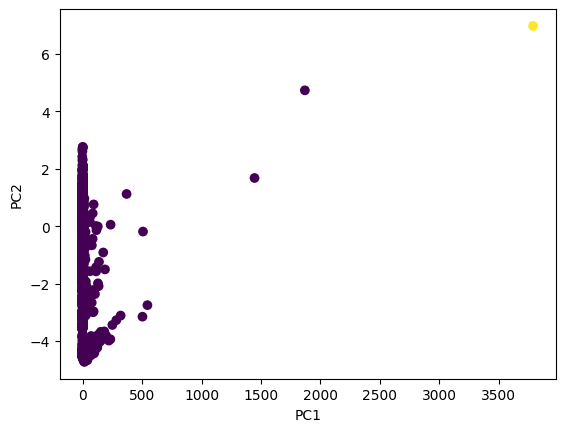

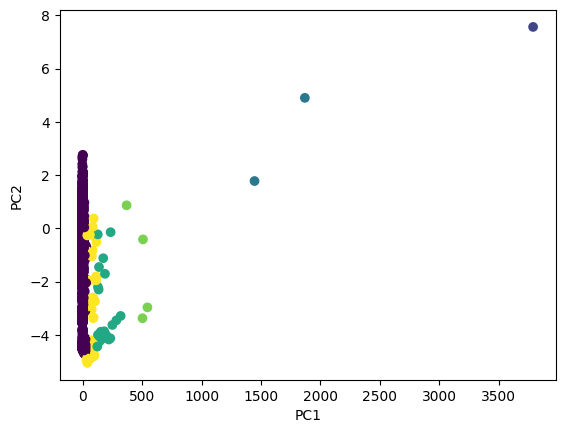

In [358]:
cluster_and_show(n_clusters=2)
cluster_and_show(n_clusters=6)

In [351]:
X_sanitized, df_sanitized = get_sanitized_features_and_org_df(df)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
kmeans = KMeans(n_clusters=6, init="k-means++", n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled_as_array)
X_sanitized["cluster"] = labels
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
display(cluster_summary)
pd.Series(labels).value_counts()
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = labels
display(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"]))
display(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"]))


mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
0                    51.672795  23.407753   1.505000  94.356250   
1                    24.949333        NaN  24.949333  24.949333   
2                    14.457917   1.457229  13.427500  15.488333   
3                    28.099663  13.036580   4.636000  47.133537   
4                    29.853551  17.790717  14.170000  55.329807   
5                    26.187711  12.908911   5.927114  65.922497   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
0           19595.200610  5157.538168   2588.723328  29360.436747   
1            3093.520010          NaN   3093.520010   3093.520010   
2           14264.570630  4899.312835  10800.233301  17728.907959   
3            7301.827906  5887.198074   2905.721680  19947.100000   
4           10105.672937  8123.276095   2823.696663  19176.105469   
5            8568.072807  6642.401171   2660.485742  21726.773315   

        time_per_1000_steps_sec                                     
                           mean        std         min         max  
cluster                                                             
0                      0.637022   0.750473    0.210316    8.601215  
1                    912.552125        NaN  912.552125  912.552125  
2                    399.798652  72.003606  348.884414  450.712891  
3                     44.058796  13.500868   30.806277   78.025852  
4                    116.901984  18.468286   90.034521  132.191891  
5                     16.777110   5.891471    8.858115   28.999889

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
0,2583,1907,383,312,14,111,164,19,18,20,22
1,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,1,0,0
3,4,0,7,4,2,2,1,1,0,1,0
4,0,0,0,2,0,0,0,0,2,0,0
5,13,7,12,5,0,7,4,5,0,4,3


training_type,ppo,sac
cluster,,
0,5514,39
1,0,1
2,0,2
3,10,12
4,1,3
5,9,51


In [320]:
X_sanitized.corr()

,mean_cpu_usage_percent,mean_ram_used_mb,time_per_1000_steps_sec
mean_cpu_usage_percent,1.000000,0.694620,-0.076193
mean_ram_used_mb,0.694620,1.000000,-0.119185
time_per_1000_steps_sec,-0.076193,-0.119185,1.000000
